# Project 1 · Olist 电商用户分析  
## Phase 1 · Block 1：数据载入与初步探索  

目标：  
1. 正确载入真实业务数据集（Olist）  
2. 了解数据的基本结构（行数、列名、数据类型）  
3. 初步感知用户、订单、金额等核心字段  
4. 为后续清洗与分析打基础  

In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

print("Environment ready")

Environment ready


In [2]:
import os
print(os.getcwd())
print(os.listdir())


C:\Users\lenovo\data_analysis_training\project_1_user_analysis
['.ipynb_checkpoints', 'data', 'Olist.ipynb', 'processed_delivered_final.csv']


In [3]:
import os
print(os.getcwd())
print(os.listdir())


C:\Users\lenovo\data_analysis_training\project_1_user_analysis
['.ipynb_checkpoints', 'data', 'Olist.ipynb', 'processed_delivered_final.csv']


In [4]:
orders = pd.read_csv("../olist_orders_dataset.csv")
orders.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [5]:
orders.shape

(99441, 8)

In [6]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [7]:
orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')

In [8]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [9]:
import pandas as pd
orders = pd.read_csv("../olist_orders_dataset.csv")
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])
orders[["order_purchase_timestamp"]].head()

,order_purchase_timestamp
0,2017-10-02 10:56:33
1,2018-07-24 20:41:37
2,2018-08-08 08:38:49
3,2017-11-18 19:28:06
4,2018-02-13 21:18:39


In [10]:
time_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

In [11]:
orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')

In [12]:
for c in time_cols:
    orders[c] = pd.to_datetime(orders[c], errors="coerce")

In [13]:
orders[time_cols].dtypes

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [14]:
orders[time_cols].isna().sum()

order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [15]:
delivered = orders[orders["order_status"] == "delivered"].copy()

In [16]:
delivered["delivery_days"] = (
    delivered["order_delivered_customer_date"]
    - delivered["order_purchase_timestamp"]
).dt.total_seconds() / 86400

In [17]:
delivered["is_late"] = (
    delivered["order_delivered_customer_date"]
    > delivered["order_estimated_delivery_date"]
)

In [18]:
late_rate = delivered["is_late"].mean()
late_rate

np.float64(0.08111693857667032)

In [19]:
delivered[["delivery_days", "is_late"]].head()


,delivery_days,is_late
0,8.436574,False
1,13.782037,False
2,9.394213,False
3,13.208750,False
4,2.873877,False


Phase 1 · Block 2：订单数据清洗与物流指标分析

目标：
1. 对 Olist 订单数据的关键时间字段进行类型标准化
2. 构建物流效率指标（交付耗时、延迟标记）
3. 分析平台整体交付表现与异常订单情况

关键产出：
- 将 5 个订单时间字段统一转换为 datetime 类型（处理缺失值为 NaT）  
- 构建 delivery_days 与 is_late 两个核心分析字段  
- 计算得到平台整体延迟率约为 8.1%  
- 发现存在少量极端慢单（交付耗时 > 60 天），为后续异常值处理提供依据  

In [20]:
import matplotlib.pyplot as plt

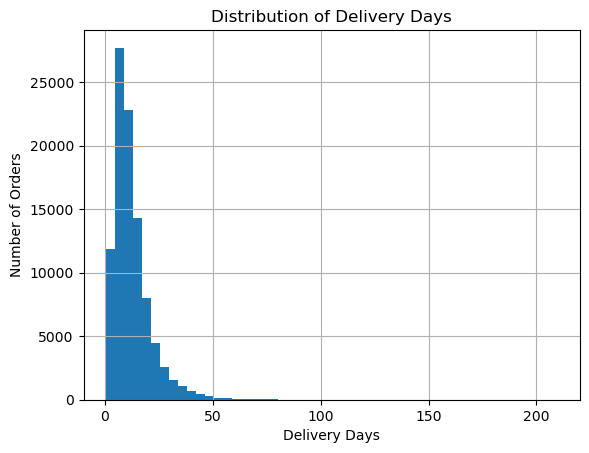

In [21]:
plt.figure()
delivered["delivery_days"].hist(bins=50)
plt.title("Distribution of Delivery Days")
plt.xlabel("Delivery Days")
plt.ylabel("Number of Orders")
plt.show()

In [22]:
delivered["delivery_days"].describe()

count    96470.000000
mean        12.558217
std          9.546156
min          0.533414
25%          6.766204
50%         10.217477
75%         15.720182
max        209.628611
Name: delivery_days, dtype: float64

In [23]:
slow_orders = delivered[delivered["delivery_days"] > 60]
slow_orders.shape

(306, 10)

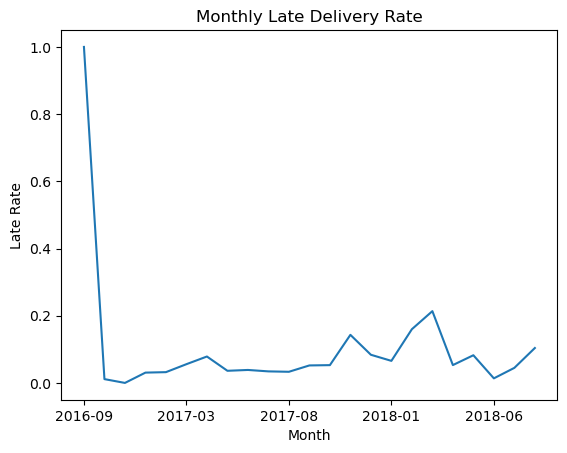

In [24]:
delivered["purchase_month"] = (
    delivered["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)
monthly_late_rate = delivered.groupby("purchase_month")["is_late"].mean()
plt.figure()
monthly_late_rate.plot(kind="line")
plt.title("Monthly Late Delivery Rate")
plt.xlabel("Month")
plt.ylabel("Late Rate")
plt.show()

In [25]:
slow_orders = delivered[delivered["delivery_days"] > 60].copy()
slow_orders["purchase_month"].value_counts().head(10)

purchase_month
2018-02    54
2018-03    37
2018-01    32
2017-11    31
2017-12    25
2017-03    20
2018-04    19
2017-06    11
2017-07     9
2017-04     8
Name: count, dtype: int64

In [26]:
avg_with_outliers = delivered["delivery_days"].mean()
avg_with_outliers

np.float64(12.558217098051975)

In [27]:
avg_without_outliers = delivered[delivered["delivery_days"] <= 60]["delivery_days"].mean()
avg_without_outliers

np.float64(12.322127429371239)

In [28]:
delivered_clean = delivered[delivered["delivery_days"] <=60].copy()
delivered_clean.shape

(96164, 11)

In [29]:
late_rate_raw = delivered["is_late"].mean()
late_rate_raw

np.float64(0.08111693857667032)

In [30]:
late_rate_clean = delivered_clean["is_late"].mean()
late_rate_clean

np.float64(0.07823093881286136)

In [31]:
monthly_total_orders = delivered["purchase_month"].value_counts().sort_index()
monthly_total_orders.head(10)

purchase_month
2016-09       1
2016-10     265
2016-12       1
2017-01     750
2017-02    1653
2017-03    2546
2017-04    2303
2017-05    3546
2017-06    3135
2017-07    3872
Name: count, dtype: int64

In [32]:
mothly_slow_orders = slow_orders["purchase_month"].value_counts()
slow_ratio = (mothly_slow_orders / monthly_total_orders).sort_index()
slow_ratio.head(10)

purchase_month
2016-09         NaN
2016-10    0.011321
2016-12         NaN
2017-01    0.009333
2017-02    0.003630
2017-03    0.007855
2017-04    0.003474
2017-05    0.001974
2017-06    0.003509
2017-07    0.002324
Name: count, dtype: float64

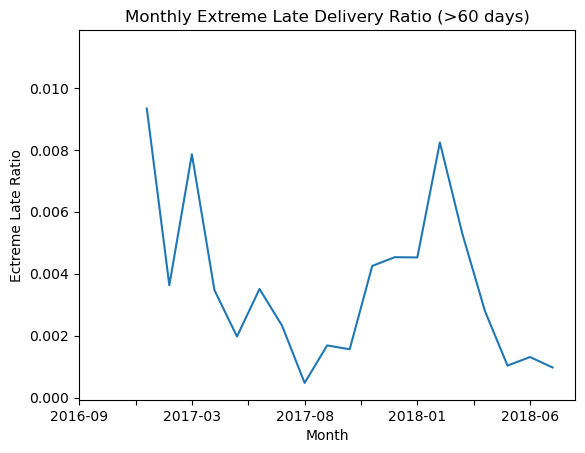

In [33]:
import matplotlib.pyplot as plt
plt.figure()
slow_ratio.plot(kind="line")
plt.title("Monthly Extreme Late Delivery Ratio (>60 days)")
plt.xlabel("Month")
plt.ylabel("Ectreme Late Ratio")
plt.show()

Phase 1 · Block 3：多表关联与分析主表构建

目标：
1. 载入并理解 customers、order_items、payments、sellers 等业务表  
2. 验证各表主键与外键关系的完整性  
3. 将清洗后的订单表（delivered_clean）与其他表进行多表 JOIN  
4. 构建统一的“分析宽表”（Analytical Dataset）  
5. 为后续用户行为、商品表现与卖家分析提供数据基础  

关键产出：
- 验证 orders ↔ customers 之间的主外键匹配率为 100%  
- 成功将客户地理信息合并进订单主表  
- 构建包含订单、用户、商品、支付与卖家信息的统一分析数据集  
- 明确一对多关系（orders → order_items / payments）并处理行数膨胀问题  

In [34]:
customers = pd.read_csv("../olist_customers_dataset.csv")
customers.shape
customers.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state'], dtype='object')

In [35]:
customers["customer_id"].nunique(), len(customers)

(99441, 99441)

In [36]:
delivered_clean = delivered[delivered["delivery_days"] <= 60].copy()
delivered_clean["customer_id"].isin(customers["customer_id"]).mean()


np.float64(1.0)

In [37]:
delivered_with_customers = delivered_clean.merge(
    customers,
    on="customer_id",
    how="left"
)
delivered_with_customers.shape

(96164, 15)

In [38]:
delivered_clean.shape
delivered_with_customers.shape

(96164, 15)

In [39]:
order_items = pd.read_csv("../olist_order_items_dataset.csv")
order_items.shape
order_items.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value'], dtype='object')

In [40]:
order_items["order_id"].value_counts().head()

order_id
8272b63d03f5f79c56e9e4120aec44ef    21
1b15974a0141d54e36626dca3fdc731a    20
ab14fdcfbe524636d65ee38360e22ce8    20
9ef13efd6949e4573a18964dd1bbe7f5    15
428a2f660dc84138d969ccd69a0ab6d5    15
Name: count, dtype: int64

In [41]:
orders_items_joined = delivered_with_customers.merge(
    order_items,
    on="order_id",
    how="left"
)
orders_items_joined.shape

(109856, 21)

In [42]:
delivered_with_customers.shape, orders_items_joined.shape

((96164, 15), (109856, 21))

In [43]:
order_level = (
    order_items
    .groupby("order_id")
    .agg(
        num_items=("order_item_id", "count"),
        order_total_price=("price", "sum"),
        order_total_freight=("freight_value", "sum")
    )
    .reset_index()
)
    
order_level.shape
order_level.head()

,order_id,num_items,order_total_price,order_total_freight
0,00010242fe8c5a6d1ba2dd792cb16214,1,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,199.90,18.14


In [44]:
delivered_full = delivered_with_customers.merge(
    order_level,
    on="order_id",
    how="left"
)
delivered_full.shape, delivered_with_customers.shape

((96164, 18), (96164, 15))

In [45]:
payments = pd.read_csv("../olist_order_payments_dataset.csv")
payments.shape
payments.columns

Index(['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value'], dtype='object')

In [46]:
payments["order_id"].value_counts().head()

order_id
fa65dad1b0e818e3ccc5cb0e39231352    29
ccf804e764ed5650cd8759557269dc13    26
285c2e15bebd4ac83635ccc563dc71f4    22
895ab968e7bb0d5659d16cd74cd1650c    21
fedcd9f7ccdc8cba3a18defedd1a5547    19
Name: count, dtype: int64

In [47]:
payment_level = (
    payments
    .groupby("order_id")
    .agg(
        total_payment_value=("payment_value", "sum"),
        num_payments=("payment_sequential", "count"),
        max_installments=("payment_installments", "max")
    )
    .reset_index()
)
payment_level.shape
payment_level.head()

,order_id,total_payment_value,num_payments,max_installments
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,1,2
1,00018f77f2f0320c557190d7a144bdd3,259.83,1,3
2,000229ec398224ef6ca0657da4fc703e,216.87,1,5
3,00024acbcdf0a6daa1e931b038114c75,25.78,1,2
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,1,3


In [48]:
delivered_final = delivered_full.merge(
    payment_level,
    on="order_id",
    how="left"
)
delivered_final.shape, delivered_full.shape

((96164, 21), (96164, 18))

# Phase 2 · EDA + Business Insights
# Block 1 · Data Health Check & Baseline Understanding

本阶段目标：
- 对 delivered_final 主分析表做工程级“数据体检”
- 确认数据粒度、字段类型、缺失情况、基础分布
- 为后续业务问题分析建立可靠基线

In [49]:
df = delivered_final
df.shape

(96164, 21)

In [50]:
df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date',
       'delivery_days', 'is_late', 'purchase_month', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'num_items', 'order_total_price', 'order_total_freight', 'total_payment_value',
       'num_payments', 'max_installments'],
      dtype='object')

In [51]:
df.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
delivery_days                           float64
is_late                                    bool
purchase_month                           object
customer_unique_id                       object
customer_zip_code_prefix                  int64
customer_city                            object
customer_state                           object
num_items                                 int64
order_total_price                       float64
order_total_freight                     float64
total_payment_value                     float64
num_payments                            float64
max_installments                        

In [52]:
missing = df.isna().mean().sort_values(ascending=False)
missing

order_approved_at                0.000146
num_payments                     0.000010
max_installments                 0.000010
total_payment_value              0.000010
order_delivered_carrier_date     0.000010
order_purchase_timestamp         0.000000
order_status                     0.000000
customer_id                      0.000000
order_id                         0.000000
is_late                          0.000000
order_delivered_customer_date    0.000000
order_estimated_delivery_date    0.000000
delivery_days                    0.000000
customer_zip_code_prefix         0.000000
customer_unique_id               0.000000
purchase_month                   0.000000
customer_city                    0.000000
order_total_price                0.000000
num_items                        0.000000
customer_state                   0.000000
order_total_freight              0.000000
dtype: float64

In [53]:
df["delivery_days"].describe()

count    96164.000000
mean        12.322127
std          8.372745
min          0.533414
25%          6.753258
50%         10.198021
75%         15.585145
max         59.998021
Name: delivery_days, dtype: float64

In [54]:
df["is_late"].value_counts(normalize=True)

is_late
False    0.921769
True     0.078231
Name: proportion, dtype: float64

In [55]:
state_stats = (
    df.groupby("customer_state")
    .agg(
        num_orders=("order_id", "count"),
        late_rate=("is_late", "mean")
    )
    .reset_index()
)
state_stats.shape

(27, 3)

In [56]:
state_stats.head()

,customer_state,num_orders,late_rate
0,AC,78,0.012821
1,AL,394,0.233503
2,AM,144,0.034722
3,AP,66,0.030303
4,BA,3228,0.132900


In [57]:
state_stats_filtered = state_stats[state_stats["num_orders"] >= 500]
state_stats_filtered.shape

(17, 3)

In [58]:
state_stats_sorted = state_stats_filtered.sort_values(
    by="late_rate",
    ascending=False
)
state_stats_sorted.head()

,customer_state,num_orders,late_rate
9,MA,712,0.191011
5,CE,1257,0.139220
4,BA,3228,0.132900
18,RJ,12253,0.127887
7,ES,1986,0.118328


In [59]:
state_stats_sorted.tail()

,customer_state,num_orders,late_rate
22,RS,5334,0.069741
12,MT,882,0.063492
25,SP,40440,0.057690
10,MG,11343,0.055276
17,PR,4917,0.048810


In [60]:
national_late_rate = df["is_late"].mean()
national_late_rate

np.float64(0.07823093881286136)

In [61]:
state_risk = state_stats_sorted.copy()
state_risk["late_rate_diff"] = (
state_risk["late_rate"] - national_late_rate
)
state_risk["late_rate_ratio"] = (
    state_risk["late_rate"] / national_late_rate
)
state_risk.head()

,customer_state,num_orders,late_rate,late_rate_diff,late_rate_ratio
9,MA,712,0.191011,0.112780,2.441633
5,CE,1257,0.139220,0.060989,1.779608
4,BA,3228,0.132900,0.054669,1.698812
18,RJ,12253,0.127887,0.049656,1.634737
7,ES,1986,0.118328,0.040097,1.512551


In [62]:
state_risk_sorted = state_risk.sort_values(
    by="late_rate_diff",
    ascending=False
)
state_risk_sorted.head(5)
state_risk_sorted.tail(5)

,customer_state,num_orders,late_rate,late_rate_diff,late_rate_ratio
22,RS,5334,0.069741,-0.008490,0.891480
12,MT,882,0.063492,-0.014739,0.811598
25,SP,40440,0.057690,-0.020541,0.737437
10,MG,11343,0.055276,-0.022955,0.706580
17,PR,4917,0.048810,-0.029421,0.623925


In [63]:
high_risk_states = state_risk_sorted.head(5)
high_risk_states

,customer_state,num_orders,late_rate,late_rate_diff,late_rate_ratio
9,MA,712,0.191011,0.112780,2.441633
5,CE,1257,0.139220,0.060989,1.779608
4,BA,3228,0.132900,0.054669,1.698812
18,RJ,12253,0.127887,0.049656,1.634737
7,ES,1986,0.118328,0.040097,1.512551


In [64]:
low_risk_states = state_risk_sorted.tail(5)
low_risk_states

,customer_state,num_orders,late_rate,late_rate_diff,late_rate_ratio
22,RS,5334,0.069741,-0.008490,0.891480
12,MT,882,0.063492,-0.014739,0.811598
25,SP,40440,0.057690,-0.020541,0.737437
10,MG,11343,0.055276,-0.022955,0.706580
17,PR,4917,0.048810,-0.029421,0.623925


In [65]:
state_risk_display = state_risk_sorted.copy()
state_risk_display["late_rate_pct"] = (
    state_risk_display["late_rate"] * 100
).round(2)
state_risk_display["late_rate_diff_pct"] = (
    state_risk_display["late_rate_diff"] * 100
).round(2)
state_risk_display["late_rate_ratio"] = (
    state_risk_display["late_rate_ratio"]
).round(2)
state_risk_display.head()

,customer_state,num_orders,late_rate,late_rate_diff,late_rate_ratio,late_rate_pct,late_rate_diff_pct
9,MA,712,0.191011,0.112780,2.44,19.10,11.28
5,CE,1257,0.139220,0.060989,1.78,13.92,6.10
4,BA,3228,0.132900,0.054669,1.70,13.29,5.47
18,RJ,12253,0.127887,0.049656,1.63,12.79,4.97
7,ES,1986,0.118328,0.040097,1.51,11.83,4.01


In [66]:
high_risk_states = state_risk_sorted.head(5)["customer_state"].tolist()
low_risk_states = state_risk_sorted.tail(5)["customer_state"].tolist()
high_risk_states, low_risk_states

(['MA', 'CE', 'BA', 'RJ', 'ES'], ['RS', 'MT', 'SP', 'MG', 'PR'])

In [67]:
df = delivered_final

In [68]:
df_high = df[df["customer_state"].isin(high_risk_states)]
df_high.shape

(19436, 21)

In [69]:
df_low = df[df["customer_state"].isin(low_risk_states)]
df_low.shape

(62916, 21)

In [70]:
df_high = df_high.copy()
df_high["risk_group"] = "High Risk"

In [71]:
df_low = df_low.copy()
df_low["risk_group"] = "Low Risk"

In [72]:
df_compare = pd.concat([df_high, df_low], axis=0)
df_compare.shape
df_compare["risk_group"].value_counts()

risk_group
Low Risk     62916
High Risk    19436
Name: count, dtype: int64

In [73]:
df_compare[["order_total_price", "order_total_freight", "num_items"]].head()

,order_total_price,order_total_freight,num_items
1,118.70,22.76,1
6,59.99,15.17,1
9,198.00,61.06,2
15,1299.00,77.45,1
18,76.00,16.97,1


In [74]:
group_profile = (
    df_compare.groupby("risk_group")
    .agg(
        mean_price=("order_total_price", "mean"),
        median_price=("order_total_price", "median"),
        mean_freight=("order_total_freight", "mean"),
        median_freight=("order_total_freight", "median"),
        mean_items=("num_items", "mean"),
        median_items=("num_items", "median"),
    )
    .reset_index()
)
group_profile
                                

,risk_group,mean_price,median_price,mean_freight,median_freight,mean_items,median_items
0,High Risk,145.649261,90.00,26.507291,19.03,1.137374,1.0
1,Low Risk,129.535270,79.99,19.758795,15.44,1.145718,1.0


In [75]:
profile_pivot = group_profile.set_index("risk_group")
diff_profile = pd.DataFrame({
    "mean_price_diff": profile_pivot.loc["High Risk", "mean_price"] - profile_pivot.loc["Low Risk", "mean_price"],
    "median_price_diff": profile_pivot.loc["High Risk", "median_price"] - profile_pivot.loc["Low Risk", "median_price"],
    "mean_freight_diff": profile_pivot.loc["High Risk", "mean_freight"] - profile_pivot.loc["Low Risk", "mean_freight"],
    "median_freight_diff": profile_pivot.loc["High Risk", "median_freight"] - profile_pivot.loc["Low Risk", "median_freight"],
    "mean_items_diff": profile_pivot.loc["High Risk", "mean_items"] - profile_pivot.loc["Low Risk", "mean_items"],
    "median_items_diff": profile_pivot.loc["High Risk", "median_items"] - profile_pivot.loc["Low Risk", "median_items"],
}, index=["High - Low"])
diff_profile

,mean_price_diff,median_price_diff,mean_freight_diff,median_freight_diff,mean_items_diff,median_items_diff
High - Low,16.11399,10.01,6.748496,3.59,-0.008344,0.0


In [76]:
profile_summary = pd.concat([group_profile, diff_profile], axis=0)
profile_summary

,risk_group,mean_price,median_price,mean_freight,median_freight,mean_items,median_items,mean_price_diff,median_price_diff,mean_freight_diff,median_freight_diff,mean_items_diff,median_items_diff
0,High Risk,145.649261,90.00,26.507291,19.03,1.137374,1.0,NaN,NaN,NaN,NaN,NaN,NaN
1,Low Risk,129.535270,79.99,19.758795,15.44,1.145718,1.0,NaN,NaN,NaN,NaN,NaN,NaN
High - Low,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.11399,10.01,6.748496,3.59,-0.008344,0.0


In [77]:
month_stats = (
    df.groupby("purchase_month")
    .agg(
        num_orders=("order_id", "count"),
        late_rate=("is_late", "mean")
    )
    .reset_index()
)
month_stats

,purchase_month,num_orders,late_rate
0,2016-09,1,1.000000
1,2016-10,262,0.003817
2,2016-12,1,0.000000
3,2017-01,743,0.021534
4,2017-02,1647,0.028537
5,2017-03,2526,0.048298
6,2017-04,2295,0.075381
7,2017-05,3538,0.034200
8,2017-06,3124,0.035531
9,2017-07,3863,0.032099


In [78]:
month_stats.shape

(23, 3)

In [79]:
month_stats

,purchase_month,num_orders,late_rate
0,2016-09,1,1.000000
1,2016-10,262,0.003817
2,2016-12,1,0.000000
3,2017-01,743,0.021534
4,2017-02,1647,0.028537
5,2017-03,2526,0.048298
6,2017-04,2295,0.075381
7,2017-05,3538,0.034200
8,2017-06,3124,0.035531
9,2017-07,3863,0.032099


In [80]:
month_stats_sorted = month_stats.sort_values(by="purchase_month")
month_stats_sorted

,purchase_month,num_orders,late_rate
0,2016-09,1,1.000000
1,2016-10,262,0.003817
2,2016-12,1,0.000000
3,2017-01,743,0.021534
4,2017-02,1647,0.028537
5,2017-03,2526,0.048298
6,2017-04,2295,0.075381
7,2017-05,3538,0.034200
8,2017-06,3124,0.035531
9,2017-07,3863,0.032099


In [81]:
month_stats_sorted =month_stats_sorted.copy()
month_stats_sorted["late_rate_diff"] = (
    month_stats_sorted["late_rate"] - national_late_rate
)
month_stats_sorted["late_rate_ratio"] = (
    month_stats_sorted["late_rate"] / national_late_rate
)
month_stats_sorted

,purchase_month,num_orders,late_rate,late_rate_diff,late_rate_ratio
0,2016-09,1,1.000000,0.921769,12.782666
1,2016-10,262,0.003817,-0.074414,0.048789
2,2016-12,1,0.000000,-0.078231,0.000000
3,2017-01,743,0.021534,-0.056697,0.275266
4,2017-02,1647,0.028537,-0.049694,0.364776
5,2017-03,2526,0.048298,-0.029933,0.617373
6,2017-04,2295,0.075381,-0.002850,0.963574
7,2017-05,3538,0.034200,-0.044031,0.437169
8,2017-06,3124,0.035531,-0.042700,0.454186
9,2017-07,3863,0.032099,-0.046132,0.410316


In [82]:
month_stats_sorted.sort_values(by="late_rate_diff",ascending=False).head(3)
month_stats_sorted.sort_values(by="late_rate_diff",ascending=False).tail(3)

,purchase_month,num_orders,late_rate,late_rate_diff,late_rate_ratio
20,2018-06,6088,0.012319,-0.065912,0.157474
1,2016-10,262,0.003817,-0.074414,0.048789
2,2016-12,1,0.000000,-0.078231,0.000000


In [83]:
month_stats_filtered = month_stats_sorted[month_stats_sorted["num_orders"] >= 500]
month_stats_filtered.shape
month_stats_filtered

,purchase_month,num_orders,late_rate,late_rate_diff,late_rate_ratio
3,2017-01,743,0.021534,-0.056697,0.275266
4,2017-02,1647,0.028537,-0.049694,0.364776
5,2017-03,2526,0.048298,-0.029933,0.617373
6,2017-04,2295,0.075381,-0.002850,0.963574
7,2017-05,3538,0.034200,-0.044031,0.437169
8,2017-06,3124,0.035531,-0.042700,0.454186
9,2017-07,3863,0.032099,-0.046132,0.410316
10,2017-08,4191,0.032689,-0.045542,0.417854
11,2017-09,4143,0.050447,-0.027784,0.644841
12,2017-10,4471,0.051443,-0.026788,0.657574


In [84]:
month_stats_filtered.sort_values(by="late_rate_diff",ascending=False).head(3)

,purchase_month,num_orders,late_rate,late_rate_diff,late_rate_ratio
17,2018-03,6966,0.209446,0.131215,2.677277
16,2018-02,6501,0.152900,0.074669,1.954464
13,2017-11,7257,0.139452,0.061221,1.782563


In [85]:
month_stats_filtered.sort_values(by="late_rate_diff",ascending=False).tail(3)

,purchase_month,num_orders,late_rate,late_rate_diff,late_rate_ratio
4,2017-02,1647,0.028537,-0.049694,0.364776
3,2017-01,743,0.021534,-0.056697,0.275266
20,2018-06,6088,0.012319,-0.065912,0.157474


In [86]:
import os

base_dir = "data"
processed_dir = os.path.join(base_dir, "processed")

os.makedirs(processed_dir, exist_ok=True)

processed_dir

'data\\processed'

In [87]:
export_tables = {
    "delivered_final": delivered_final,
    "state_risk_by_state": state_risk_display,
    "high_vs_low_profile": profile_summary,
    "monthly_delay_stats": month_stats_filtered
}
list(export_tables.keys())

['delivered_final',
 'state_risk_by_state',
 'high_vs_low_profile',
 'monthly_delay_stats']

In [88]:
for name, df_obj in export_tables.items():
    file_path = os.path.join(processed_dir, f"{name}.csv")
    df_obj.to_csv(file_path, index=False)
    print(f"Exported: {file_path}")

Exported: data\processed\delivered_final.csv
Exported: data\processed\state_risk_by_state.csv
Exported: data\processed\high_vs_low_profile.csv
Exported: data\processed\monthly_delay_stats.csv


# Phase 3 · Predictive Modeling（可解释 · 业务导向）

> **目标**：构建一个可解释、可落地、可写进简历的预测模型，用于**提前识别可能发生延迟的订单**，并清楚说明：  
> - 为什么选择该模型  
> - 特征从哪里来  
> - 评估结果意味着什么  
> 本 Phase 不追求刷复杂模型，而是**工程级流程 + 业务直觉建立**。

In [89]:
delivered_final.shape
delivered_final.to_csv(
    "processed_delivered_final.csv",
    index=False
)

In [90]:
import os
os.listdir()

['.ipynb_checkpoints', 'data', 'Olist.ipynb', 'processed_delivered_final.csv']

In [91]:
df = pd.read_csv("processed_delivered_final.csv")
df.shape

(96164, 21)

In [92]:
target = "is_late"
df[target].value_counts(dropna=False), df[target].mean()

(is_late
 False    88641
 True      7523
 Name: count, dtype: int64,
 np.float64(0.07823093881286136))

In [93]:
keywords = ["delivered", "delivery", "estimate", "approved", "purchase", "late", "days", "date", "timestamp"]
suspects = [c for c in df.columns if any(k in c.lower() for k in keywords)]
len(suspects), suspects[:50]

(8,
 ['order_purchase_timestamp',
  'order_approved_at',
  'order_delivered_carrier_date',
  'order_delivered_customer_date',
  'order_estimated_delivery_date',
  'delivery_days',
  'is_late',
  'purchase_month'])

In [94]:
late_rate = df[target].mean()
baseline_acc = max(late_rate, 1 - late_rate)
late_rate, baseline_acc

(np.float64(0.07823093881286136), np.float64(0.9217690611871386))

In [95]:
leakage_cols = [
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "delivery_days",
    "is_late"
]   

In [96]:
[c for c in leakage_cols if c in df.columns]

['order_delivered_carrier_date',
 'order_delivered_customer_date',
 'delivery_days',
 'is_late']

In [97]:
df_model = df.drop(columns=leakage_cols)
df_model.shape
df_model.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at',
       'order_estimated_delivery_date', 'purchase_month', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state', 'num_items', 'order_total_price', 'order_total_freight',
       'total_payment_value', 'num_payments', 'max_installments'],
      dtype='object')

In [98]:
df_model["order_purchase_timestamp"] = pd.to_datetime(
    df_model["order_purchase_timestamp"]
)

In [99]:
df_model = df_model.sort_values("order_purchase_timestamp")

In [100]:
split_point = int(len(df_model) * 0.8)
train_df = df_model.iloc[:split_point]
test_df = df_model.iloc[split_point:]

In [101]:
train_df.shape, test_df.shape

((76931, 17), (19233, 17))

In [102]:
train_df["order_purchase_timestamp"].max()

Timestamp('2018-05-27 11:44:23')

In [103]:
test_df["order_purchase_timestamp"].min()

Timestamp('2018-05-27 11:55:26')

In [104]:
y_train = df.loc[train_df.index, "is_late"]
y_test = df.loc[test_df.index, "is_late"]
y_train.shape, y_test.shape

((76931,), (19233,))

In [105]:
y_train.value_counts(normalize=True)
y_test.value_counts(normalize=True)

is_late
False    0.947694
True     0.052306
Name: proportion, dtype: float64

In [106]:
X_train = train_df
X_test = test_df
X_train.shape, y_train.shape
X_test.shape, y_test.shape

((19233, 17), (19233,))

In [107]:
X_train.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                        object
order_estimated_delivery_date            object
purchase_month                           object
customer_unique_id                       object
customer_zip_code_prefix                  int64
customer_city                            object
customer_state                           object
num_items                                 int64
order_total_price                       float64
order_total_freight                     float64
total_payment_value                     float64
num_payments                            float64
max_installments                        float64
dtype: object

In [108]:
numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
numeric_cols

Index(['customer_zip_code_prefix', 'num_items', 'order_total_price', 'order_total_freight', 'total_payment_value',
       'num_payments', 'max_installments'],
      dtype='object')

In [109]:
X_train_num = X_train[numeric_cols]
X_test_num = X_test[numeric_cols]
X_train_num.shape, X_test_num.shape

((76931, 7), (19233, 7))

In [110]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_num)
X_test_scaled = scaler.transform(X_test_num)

In [111]:
X_train_scaled.mean(axis=0)

array([ 5.98499555e-17, -8.60804916e-17,  1.84167919e-16,  6.33596751e-17,
                   nan,             nan,             nan])

In [112]:
X_train_scaled.std(axis=0)

array([ 1.,  1.,  1.,  1., nan, nan, nan])

In [113]:
X_train_scaled.shape
X_test_scaled.shape

(19233, 7)

In [114]:
X_train_num.describe()

,customer_zip_code_prefix,num_items,order_total_price,order_total_freight,total_payment_value,num_payments,max_installments
count,76931.000000,76931.000000,76931.000000,76931.000000,76930.000000,76930.000000,76930.000000
mean,35699.244804,1.144233,136.460470,22.243251,158.738776,1.046601,2.954296
std,29906.265577,0.545756,205.771513,20.275826,215.056354,0.390816,2.734884
min,1003.000000,1.000000,0.850000,0.000000,10.070000,1.000000,0.000000
25%,11722.000000,1.000000,45.900000,13.780000,61.770000,1.000000,1.000000
50%,25555.000000,1.000000,86.790000,16.790000,104.590000,1.000000,2.000000
75%,60110.000000,1.000000,149.900000,23.640000,175.640000,1.000000,4.000000
max,99980.000000,21.000000,13440.000000,1002.290000,13664.080000,26.000000,24.000000


In [115]:
selected_cols = [
    "num_items",
    "order_total_price",
    "order_total_freight",
    "total_payment_value"
]
X_train_sel = X_train[selected_cols]
X_test_sel = X_test[selected_cols]

In [116]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sel)
X_test_scaled  = scaler.transform(X_test_sel)

In [117]:
X_train_scaled.mean(axis=0)

array([-8.60804916e-17,  1.84167919e-16,  6.33596751e-17,             nan])

In [118]:
X_train_scaled.std(axis=0)

array([ 1.,  1.,  1., nan])

In [119]:
final_cols = [
    "num_items",
    "order_total_price",
    "order_total_freight"
]

In [120]:
X_train_final = X_train[final_cols]
X_test_final = X_test[final_cols]

In [121]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

In [122]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)
model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [123]:
y_pred = model.predict(X_test_scaled)

In [124]:
from sklearn.metrics import accuracy_score, recall_score, precision_score
acc = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
acc, recall, precision

(0.6062496750376957, 0.28628230616302186, 0.04031919361612768)

In [125]:
y_pred = model.predict(X_test_scaled)

In [126]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [127]:
y_prob[:10], y_prob.min(), y_prob.max()

(array([0.55742952, 0.4978987 , 0.46597463, 0.46965658, 0.46816504,
        0.49799009, 0.65286026, 0.52246157, 0.44963559, 0.48120547]),
 np.float64(0.04246188350949926),
 np.float64(0.9999999947167437))

In [128]:
thresholds = [0.2, 0.3, 0.5]

In [129]:
results = []

In [130]:
for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)

In [131]:
acc = accuracy_score(y_test, y_pred_t)
recall = recall_score(y_test, y_pred_t)
precision = precision_score(y_test, y_pred_t)

In [132]:
results.append({
    "threshold": t,
    "accuracy": acc,
    "recall": recall,
    "precision": precision
})

In [133]:
import pandas as pd
pd.DataFrame(results)

,threshold,accuracy,recall,precision
0,0.5,0.60625,0.286282,0.040319


In [134]:
thresholds
len(thresholds)

3

In [135]:
# ⚠️ 重置结果（非常关键）
results = []

from sklearn.metrics import accuracy_score, recall_score, precision_score
import pandas as pd

thresholds = [0.2, 0.3, 0.5]

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    
    acc = accuracy_score(y_test, y_pred_t)
    recall = recall_score(y_test, y_pred_t)
    precision = precision_score(y_test, y_pred_t)
    
    results.append({
        "threshold": t,
        "accuracy": acc,
        "recall": recall,
        "precision": precision
    })

pd.DataFrame(results)

,threshold,accuracy,recall,precision
0,0.2,0.05293,1.000000,0.052339
1,0.3,0.05423,0.993042,0.052080
2,0.5,0.60625,0.286282,0.040319


In [136]:
len(X_train_sel.columns), len(model.coef_[0])

(4, 3)

In [137]:
X_train_sel.columns

Index(['num_items', 'order_total_price', 'order_total_freight', 'total_payment_value'], dtype='object')

In [138]:
feature_names = ["num_items", "order_total_price", "order_total_freight"]

In [139]:
import pandas as pd
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": model.coef_[0]
}).sort_values("coef", ascending=False)
coef_df

,feature,coef
2,order_total_freight,0.237662
1,order_total_price,-0.014352
0,num_items,-0.184349


# Phase 4 · Model Interpretation & Project Elevation  
（模型解释 · 业务翻译）

**目标：**  
在不重新建模的前提下，对 Phase 3 中的 Logistic Regression 模型进行深入解释，
将模型参数与预测结果转化为**可理解、可沟通、可决策**的业务信息，
使模型具备真实项目中的**落地价值与复用价值**。

In [140]:
coef = model.coef_[0]
intercept = model.intercept_[0]
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coef
}).sort_values(by="coefficient", ascending=False)
coef_df

,feature,coefficient
2,order_total_freight,0.237662
1,order_total_price,-0.014352
0,num_items,-0.184349
